In [ ]:
# Start with imports as usual
import pandas as pd

In [22]:
# Define constants such as file locations
QUESTIONNAIRE_FOLDER = "Data/Database - exploratieve studie/vragenlijst/"
QUESTIONNAIRE_FILE_END = "_vermoeidheid_week_06-06-2025.xlsx"
SCORING_TABLE_FILE = "Data/Database - exploratieve studie/vragenlijst/Scoring_table.xlsx"
PHYSICAL_QUESTION_IDS = [9668376083, 6258701732, 6370141573, 9476467466, 6884851944]
MENTAL_QUESTION_IDS = [1266291554, 6862084566, 3776667623, 1841110800, 5185390288]
EMOTIONAL_QUESTION_IDS = [5879067772, 6804717662, 3510363114, 7361248698, 6004542048]
QUESTION16 = [4488672595]
QUESTION17 = [3457746608]
FATIGUE_QUESTION_IDS = PHYSICAL_QUESTION_IDS + MENTAL_QUESTION_IDS + EMOTIONAL_QUESTION_IDS + QUESTION16 + QUESTION17
GENERAL_INFO_COLUMNS = ["id", "patient_id", "first_name", "last_name", "intended_date", "completed_at", "completed_at_unix", "time_point", "week"]

# Questionnaire data
First we extract all of the data from the questionnaires

In [4]:
questionnaire_dfs = []
for i in range(1,10):
    df = pd.read_excel(QUESTIONNAIRE_FOLDER + "week" + str(i) + QUESTIONNAIRE_FILE_END, sheet_name="answers")
    df["week"] = i
    questionnaire_dfs.append(df)
questionnaire_df = pd.concat(questionnaire_dfs, ignore_index=True)
questionnaire_df.head()

,id,patient_id,first_name,last_name,intended_date,completed_at,completed_at_unix,time_point,question_6311607689,question_9668376083,...,question_1743598132,question_7368326683,question_6793970870,question_5787894943,question_6997037795,question_6327950113,question_5406986835,question_7080388641,question_4880213534,week
0,9748,2449,Kim,Wijlens,2023-08-01,2023-08-01 09:24:58,1690874698,1,NaN,Heel erg,...,Nee,Altijd,Altijd,Nooit,Heel erg,Heel erg,Helemaal niet,Helemaal niet,Helemaal niet,1
1,10269,2672,1,deelnemer,2023-08-17,2023-08-17 10:54:45,1692262485,1,NaN,Vaak,...,Misschien,Een beetje,Een beetje,Soms,Een beetje,Best wel,Niet,Een beetje,Meestal,1
2,12976,3268,9,deelnemer,2023-11-29,2023-11-29 13:25:54,1701260754,1,NaN,Vaak,...,Nee,Een beetje,Een beetje,Altijd,Een beetje,Helemaal niet,Waarschijnlijk,Meestal,Meestal,1
3,13254,3302,23,Deelnemer,2023-12-12,2023-12-12 08:25:18,1702365918,1,NaN,Een beetje,...,Nee,Een beetje,Een beetje,Vaak,Helemaal niet,Helemaal niet,Niet,Een beetje,Meestal,1
4,13154,3294,16,Deelnemer,2023-12-11,2023-12-12 17:19:07,1702397947,1,NaN,Een beetje,...,Zeker,Vaak,Een beetje,Altijd,Een beetje,Helemaal niet,Zeker,Meestal,Meestal,1


We also need the scoring table to transform the data to numbers, as well as extract the questions from their ids

In [9]:
scoring = pd.read_excel(SCORING_TABLE_FILE)

column_name_to_question = dict(zip("question_" + scoring["ID"].astype(str), scoring["Question"]))

id_to_score_map = {} # Quesion id -> {Possible answer: score}
for _, row in scoring.iterrows():
    qid = str(row["ID"])
    answers = [answer.strip() for answer in str(row["Possible_answers"]).split(";")]
    scores = [score.strip() for score in str(row["Scoring"]).split()]
    id_to_score_map[qid] = dict(zip([answer.lower() for answer in answers], map(float, scores)))

mapped_answers = questionnaire_df.copy()

# Replace answer strings by their value
for col, question in column_name_to_question.items():
    qid = col.split("_")[1]
    score_map = id_to_score_map[qid]
    mapped_answers[col] = mapped_answers[col].str.lower().map(score_map)

mapped_answers.head()

,id,patient_id,first_name,last_name,intended_date,completed_at,completed_at_unix,time_point,question_6311607689,question_9668376083,...,question_1743598132,question_7368326683,question_6793970870,question_5787894943,question_6997037795,question_6327950113,question_5406986835,question_7080388641,question_4880213534,week
0,9748,2449,Kim,Wijlens,2023-08-01,2023-08-01 09:24:58,1690874698,1,NaN,3.0,...,Nee,Altijd,Altijd,Nooit,Heel erg,Heel erg,Helemaal niet,Helemaal niet,Helemaal niet,1
1,10269,2672,1,deelnemer,2023-08-17,2023-08-17 10:54:45,1692262485,1,NaN,2.0,...,Misschien,Een beetje,Een beetje,Soms,Een beetje,Best wel,Niet,Een beetje,Meestal,1
2,12976,3268,9,deelnemer,2023-11-29,2023-11-29 13:25:54,1701260754,1,NaN,2.0,...,Nee,Een beetje,Een beetje,Altijd,Een beetje,Helemaal niet,Waarschijnlijk,Meestal,Meestal,1
3,13254,3302,23,Deelnemer,2023-12-12,2023-12-12 08:25:18,1702365918,1,NaN,1.0,...,Nee,Een beetje,Een beetje,Vaak,Helemaal niet,Helemaal niet,Niet,Een beetje,Meestal,1
4,13154,3294,16,Deelnemer,2023-12-11,2023-12-12 17:19:07,1702397947,1,NaN,1.0,...,Zeker,Vaak,Een beetje,Altijd,Een beetje,Helemaal niet,Zeker,Meestal,Meestal,1


In [36]:
keep_columns = GENERAL_INFO_COLUMNS + ["question_" + str(question_id) for question_id in FATIGUE_QUESTION_IDS]
fatigue_df = mapped_answers[keep_columns].copy()

fatigue_df.head()

,id,patient_id,first_name,last_name,intended_date,completed_at,completed_at_unix,time_point,week,question_9668376083,...,question_3776667623,question_1841110800,question_5185390288,question_5879067772,question_6804717662,question_3510363114,question_7361248698,question_6004542048,question_4488672595,question_3457746608
0,9748,2449,Kim,Wijlens,2023-08-01,2023-08-01 09:24:58,1690874698,1,1,3.0,...,2.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,1.0,1.00
1,10269,2672,1,deelnemer,2023-08-17,2023-08-17 10:54:45,1692262485,1,1,2.0,...,1.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,0.95
2,12976,3268,9,deelnemer,2023-11-29,2023-11-29 13:25:54,1701260754,1,1,2.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,2.0,1.00
3,13254,3302,23,Deelnemer,2023-12-12,2023-12-12 08:25:18,1702365918,1,1,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.95
4,13154,3294,16,Deelnemer,2023-12-11,2023-12-12 17:19:07,1702397947,1,1,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.90


In [37]:
#TODO: for Q17 ensure the real values remain, not just the multipliers

# Creating a df for the fatigue score calculations
fatigue_scores_df = fatigue_df[GENERAL_INFO_COLUMNS].copy()

def column_name_from_ids(ids):
    return ["question_" + str(question_id) for question_id in ids]

fatigue_scores_df["Overall_fatigue"] = (((fatigue_df[column_name_from_ids(FATIGUE_QUESTION_IDS)]
                                            .sum(axis=1))/15)/3) * 10 * fatigue_df[column_name_from_ids(QUESTION17)].squeeze()
fatigue_scores_df["Physical_fatigue"] = (((fatigue_df[column_name_from_ids(PHYSICAL_QUESTION_IDS)]
                                            .sum(axis=1))/5)/3) * 10 
fatigue_scores_df["Mental_fatigue"] = (((fatigue_df[column_name_from_ids(MENTAL_QUESTION_IDS)]
                                            .sum(axis=1))/5)/3) * 10 
fatigue_scores_df["Emotional_fatigue"] = (((fatigue_df[column_name_from_ids(EMOTIONAL_QUESTION_IDS)]
                                            .sum(axis=1))/5)/3) * 10 

fatigue_score_columns = ["Overall_fatigue", "Physical_fatigue", "Mental_fatigue", "Emotional_fatigue"]
fatigue_scores_df.head()

,id,patient_id,first_name,last_name,intended_date,completed_at,completed_at_unix,time_point,week,Overall_fatigue,Physical_fatigue,Mental_fatigue,Emotional_fatigue
0,9748,2449,Kim,Wijlens,2023-08-01,2023-08-01 09:24:58,1690874698,1,1,8.444444,8.000000,8.000000,8.000000
1,10269,2672,1,deelnemer,2023-08-17,2023-08-17 10:54:45,1692262485,1,1,4.845000,6.000000,3.333333,4.666667
2,12976,3268,9,deelnemer,2023-11-29,2023-11-29 13:25:54,1701260754,1,1,3.777778,6.666667,0.666667,2.000000
3,13254,3302,23,Deelnemer,2023-12-12,2023-12-12 08:25:18,1702365918,1,1,2.100556,3.333333,0.000000,2.000000
4,13154,3294,16,Deelnemer,2023-12-11,2023-12-12 17:19:07,1702397947,1,1,3.580000,4.000000,3.333333,3.333333


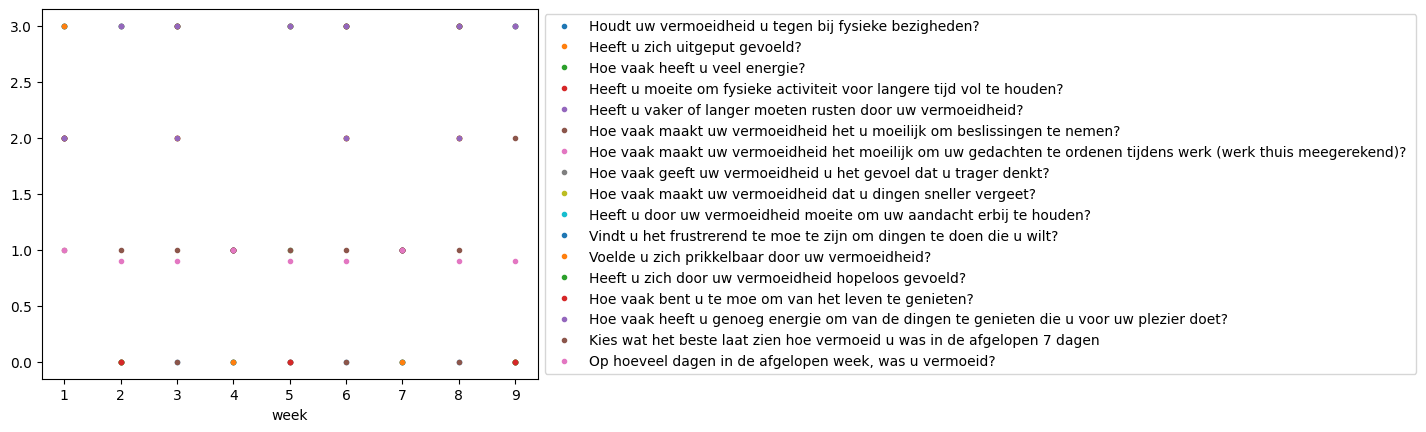

In [47]:
fatigue_df.rename(columns=column_name_to_question, inplace=True)
test_patient = fatigue_df[fatigue_df["patient_id"] == 2449].copy()
test_patient.plot(x="week", y=[question for question in column_name_to_question.values()], marker='.', linestyle='none').legend(loc='center left',bbox_to_anchor=(1.0, 0.5));

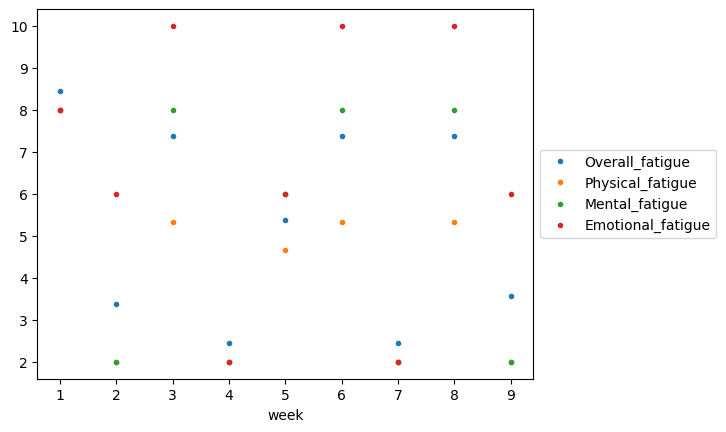

In [48]:
test_patient_scores = fatigue_scores_df[fatigue_scores_df["patient_id"] == 2449].copy()
test_patient_scores.plot(x="week", y=[*fatigue_score_columns], marker='.', linestyle='none').legend(loc='center left',bbox_to_anchor=(1.0, 0.5));